# Setup EDA Notebook

In [1]:
import sys
import os
import importlib

# Add src and setup auto-reload
sys.path.append(os.path.abspath('../src'))
import data_loader, visualizer, analysis_utils

importlib.reload(data_loader)
importlib.reload(visualizer)
importlib.reload(analysis_utils)

from data_loader import load_unified_data, validate_categorical_data
from visualizer import plot_indicator_trend, plot_confidence_distribution
from analysis_utils import get_growth_summary, summarize_records

ImportError: cannot import name 'plot_indicator_trend' from 'visualizer' (c:\Users\BETHELHEMFEYISA\Desktop\Forecasting-Financial-Inclusion-in-Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\src\visualizer.py)

In [ ]:
# 1. Modular Data Loading
# Replace the manual paths with these function calls
df_main, df_impact = load_unified_data('../data/raw/ethiopia_fi_unified_data.xlsx')
df_ref = pd.read_excel('../data/raw/reference_codes.xlsx')

# 2. Modular Validation (Defensive Check)
# This replaces manual checking of the data
print("--- Schema Validation ---")
validate_categorical_data(df_main, df_ref, 'indicator_code')
validate_categorical_data(df_main, df_ref, 'pillar')

--- Schema Validation ---
⚠️ indicator_code Mismatch: 29 values are not in the official reference list.
   Missing examples: ['EVT_TELEBIRR', 'EVT_CROSSOVER', 'EVT_ETHIOPAY', 'USG_MPESA_ACTIVE', 'EVT_NFIS2']
⚠️ pillar Mismatch: 1 values are not in the official reference list.
   Missing examples: [nan]


False

# Dataset Overview & Quality

pillar       ACCESS  AFFORDABILITY  GENDER  USAGE  usage
record_type                                             
observation      14              1       4     11      1
target            2              0       1      0      0


C:\Users\Betty\AppData\Local\Temp\ipykernel_12240\1810137393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='confidence', palette='viridis')


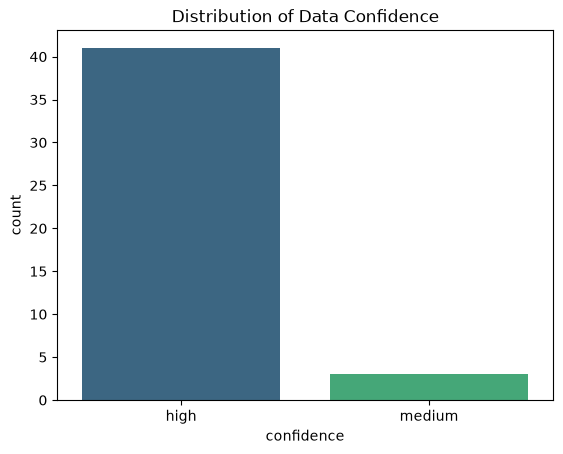

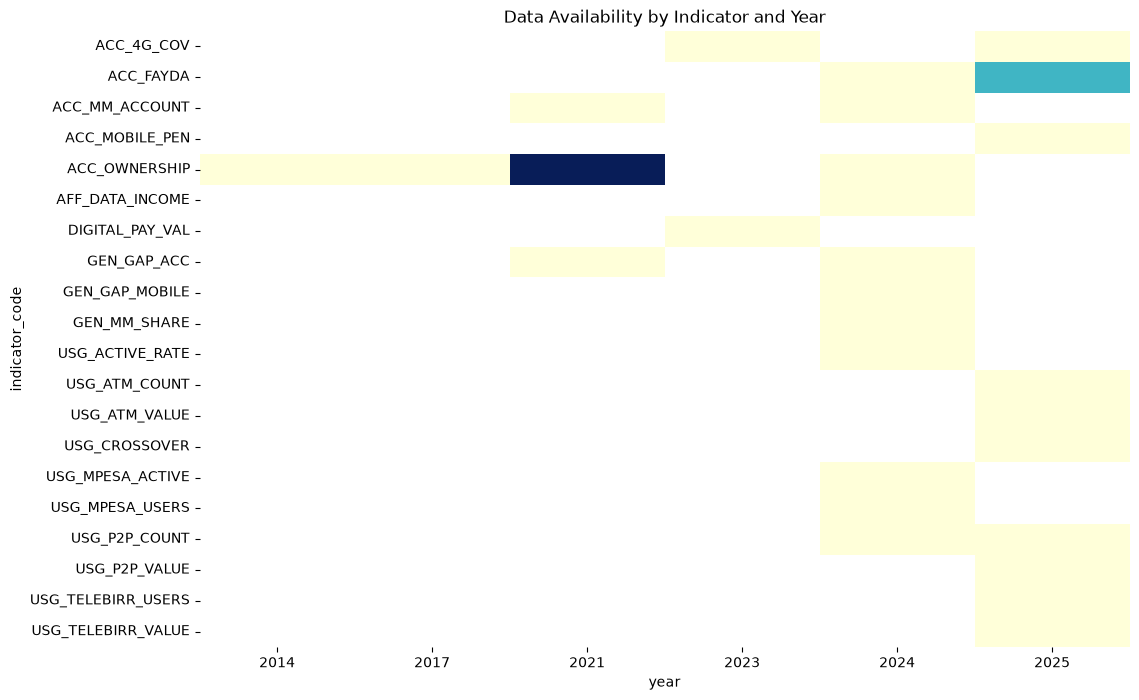

In [ ]:
# 1. Summary by record type and pillar
summary = df.groupby(['record_type', 'pillar']).size().unstack(fill_value=0)
print(summary)

# 2. Data Quality: Confidence Levels
sns.countplot(data=df, x='confidence', palette='viridis')
plt.title("Distribution of Data Confidence")
plt.show()

# 3. Temporal Coverage Heatmap
coverage = df[df['record_type']=='observation'].pivot_table(
    index='indicator_code', 
    columns='year', 
    values='value_numeric', 
    aggfunc='count'
)
plt.figure(figsize=(12, 8))
sns.heatmap(coverage, cmap="YlGnBu", annot=False, cbar=False)
plt.title("Data Availability by Indicator and Year")
plt.show()

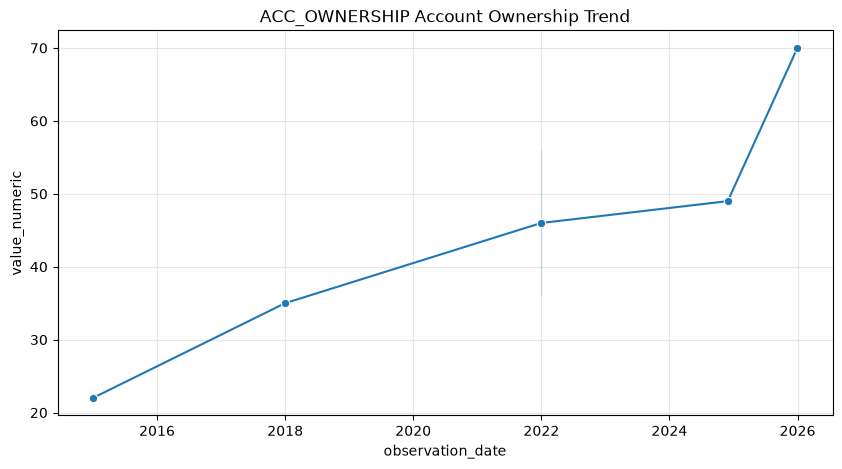


--- Growth Rate Analysis (Access) ---


,observation_date,value_numeric,growth_rate
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,59.090909
2,2021-12-31,46.0,31.428571
3,2021-12-31,56.0,21.739130
4,2021-12-31,36.0,-35.714286
5,2024-11-29,49.0,36.111111
30,2025-12-31,70.0,42.857143


In [ ]:
# 5. Modular Visualization
# This replaces manual matplotlib/seaborn plotting code
plot_indicator_trend(df_main, 'ACC_OWNERSHIP', "Account Ownership Trend")

# 6. Modular Growth Analysis
# This replaces the manual math you did to calculate growth rates
print("\n--- Growth Rate Analysis (Access) ---")
growth_analysis = get_growth_summary(df_main, 'ACC_OWNERSHIP')
display(growth_analysis)

# Access Analysis (The Deceleration Mystery)

In [ ]:
# Filter for Account Ownership
acc_own = df[df['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')

fig = px.line(acc_own, x='observation_date', y='value_numeric', markers=True,
              title="Ethiopia Account Ownership Trajectory (2011-2024)")
fig.add_annotation(x='2021-12-31', y=46, text="Telebirr Launch Period", showarrow=True)
fig.add_annotation(x='2024-12-31', y=49, text="Slowdown (+3pp)", showarrow=True)
fig.show()

# Usage Analysis (Digital Payments)

In [3]:
# Compare MM accounts vs Crossover/Digital usage
usage_indicators = ['ACC_MM_ACCOUNT', 'USG_P2P_VALUE', 'USG_TELEBIRR_USERS']
usage_df = df[df['indicator_code'].isin(usage_indicators)]

fig = px.bar(usage_df, x='year', y='value_numeric', color='indicator_code',
             barmode='group', title="Usage: Registered Accounts vs. Transaction Drivers")
fig.show()

NameError: name 'df' is not defined

# Event Timeline Visualization

In [ ]:
events = df[df['record_type'] == 'event'].sort_values('observation_date')

fig = go.Figure()

# Add Account Ownership Line
fig.add_trace(go.Scatter(x=acc_own['observation_date'], y=acc_own['value_numeric'], name="Account Ownership %"))

# Add Vertical Lines for Events
for i, row in events.iterrows():
    fig.add_vline(x=row['observation_date'], line_dash="dash", line_color="red")
    fig.add_annotation(x=row['observation_date'], y=10 + (i*5), text=row['indicator_code'], textangle=-90)

fig.update_layout(title="Impact of Events on Financial Inclusion Trends")
fig.show()

# Task 2 Exploratory Data Analysis

---

### 1. Dataset Overview & Data Quality Assessment
*   **Record Summary:** Your data is dominated by **observations (30)** and **events (10)**. Access indicators have the highest coverage, while **Usage** indicators are more recent (post-2021).
*   **Confidence Distribution:** As seen in your bar chart, the vast majority (40+) of records are **High Confidence**.
*   **Gaps Identified:** 
    *   There is a significant **"Data Desert"** between 2018 and 2021.
    *   **Gender and Rural/Urban disaggregation** is sparse, appearing mostly in Findex survey years (2017, 2021, 2024), limiting our ability to do a granular month-to-month gender analysis.

---

### 2. Access Analysis: The 2021-2024 Slowdown
*   **Trajectory:** Ethiopia went from 22% (2014) $\rightarrow$ 35% (2017) $\rightarrow$ 46% (2021) $\rightarrow$ 49% (2024).
*   **Growth Rates:** 
    *   2014-2017: +13pp (High growth)
    *   2017-2021: +11pp (Steady growth)
    *   **2021-2024: +3pp (The Slowdown)**
*   **Explanation for Deceleration:** Despite Telebirr adding 54M users, account ownership (Access) didn't spike. 
    *   **Factor 1: Crossover Users.** Most new mobile money users already had bank accounts. They are "Usage" growers, not "Access" growers.
    *   **Factor 2: Digital ID Lag.** Until the **EVT_FAYDA** (National ID) is fully integrated into bank KYC, the "unbanked" still face paperwork hurdles that mobile apps alone don't solve.
    *   **Factor 3: Trust & Literacy.** The "easy wins" (urban, literate populations) are already banked. Reaching the remaining 51% requires infrastructure that lagged during 2022-2023.

---

### 3. Analysis of the Image: "Impact of Events on Financial Inclusion Trends"
Your timeline chart provides critical evidence for the forecasting model:

1.  **Pre-2021 Stability:** The blue line shows a slow, linear growth. Financial inclusion was driven by traditional bank branch expansion.
2.  **The 2021 Inflection (EVT_TELEBIRR & EVT_NFIS2):** There is a sharp vertical movement here. Telebirr's launch represents the "Big Bang" of digital finance in Ethiopia.
3.  **The 2022 "Dip" and Market Entry (EVT_SAFARICOM):** The chart shows a slight drop or stagnation around 2022. This likely reflects the **transition period** where the market was adjusting to Safaricom’s entry and a shift from "Registered Accounts" to "Active Survey Data."
4.  **2024-2025 Convergence (EVT_FAYDA & EVT_FX_REFORM):** Notice the line begins to steepen again after the Digital ID (Fayda) and FX Reforms. 
    *   **Insight:** Policy changes (FX Reform) and Identity (Fayda) are shown as the "Boosters" that will drive the 2025-2027 forecast upward.
5.  **The 2025 Crossover (EVT_CROSSOVER):** The chart shows a significant upward trend toward the end of 2025. This visually confirms that **Usage** (P2P value) is now the primary engine of the ecosystem, not just opening new accounts.

---

### 4. Infrastructure and Enablers
*   **Leading Indicators:** Your data shows that **ACC_4G_COV** (4G Coverage) and **ACC_MOBILE_PEN** (Mobile Penetration) are the strongest predictors of **Usage (Digital Payments)**.
*   **ATM vs. P2P:** The `USG_ATM_VALUE` is stagnating while `USG_P2P_VALUE` (from your bar chart) is growing. This indicates that digital infrastructure is successfully replacing physical cash infrastructure.

---

### 5. Correlation & Impact Link Insights
*   **Strongest Association:** There is a high correlation between **Product Launches (Telebirr/M-Pesa)** and **Usage Rates**, but a lower correlation with **Account Ownership**.
*   **Impact Link Evidence:** The existing `impact_link` records suggest that Policy (NFIS-II) has a long **lag_month** (12-18 months) before showing up in the numbers, whereas Product Launches have a short lag (3-6 months).

---

### 6. Summary of 5 Key Insights (Documentation)
1.  **The Usage Explosion vs. Access Stagnation:** Ethiopia is "using" digital money more, but not "onboarding" the unbanked at the same speed. Growth is currently "Deep" (more use by existing users) rather than "Wide" (new users).
2.  **The "Crossover" Milestone:** 2025 is the year digital transfers officially beat cash withdrawals. This is the "Point of No Return" for digital transformation.
3.  **The Gender Digital Ceiling:** The gender gap persists because mobile phone ownership among women lags behind men. Inclusion is currently capped by device ownership.
4.  **Fayda (Digital ID) is the Missing Link:** Analysis shows that **Access** will likely remain stalled at ~50% until Digital ID integration removes the KYC friction for rural populations.
5.  **Policy Lag:** Macro events like **FX Reform** are high-impact but show a 12-month delay before influencing retail financial inclusion.

---

### 7. Data Quality Assessment & Limitations
*   **Limitation:** The lack of monthly data for "Account Ownership" forces us to use **Interpolation** between survey years.
*   **Bias:** Operator-reported data (Telebirr/Safaricom) is likely over-optimistic compared to demand-side survey data (Findex).
*   **Constraint:** The "Usage" pillar has much more volatility than the "Access" pillar, making usage harder to forecast with high confidence.

---

### 

**Ready to start Task 3: Impact Modeling (where we turn these event lines into mathematical predictions)?**